In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const

from mcfacts.inputs.settings_manager import AGNDisk, SettingsManager
from mcfacts.utilities import unit_conversion


In [2]:
a = [1000]
b = [1100]
np.isclose(a, b, atol=100)

array([ True])

In [3]:
sirko_agn_disk = AGNDisk(SettingsManager(
    {
        "disk_model_name": "sirko_goodman"
    }
))

thompson_agn_disk = AGNDisk(SettingsManager(
    {
        "disk_model_name": "thompson_etal"
    }
))

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 2.596689e+00 MSun/yr
le = 1.0
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.01
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Q<1 at i=3502 (R=9.06e+02 Rs)
Beginning star formation at index 3502
Mdisk = 422372550.2716628 Msun
Mdisk/Mbh = 4.223725502716627
sigma from M using M-sigma relation
### Thompson et al. 2005 parameters ###
Mbh = 1.000000e+08 MSun
Mdot_out = 3.200000e+02 MSun/yr
Rs = 9.570121e-06 pc
Rin = 3.000000e+00 Rs
Rout = 2.524924e+04 Rs = 2.416383e-01 pc
sigma = 1.879994e+02 km/s
epsilon =  0.001
m =  0.01
xi =  1.0
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
 ### Beginning integration at Rmax ###
### Switching to no star formation regime at i = 9999, R = 25237.83156757238Rs ###


/Users/jakepost/miniforge3/envs/mcfacts-dev/lib/python3.12/site-packages/pagn/Thompson.py:619: RuntimeWarning: overflow encountered in power
  T, eta = 10 ** x
/Users/jakepost/miniforge3/envs/mcfacts-dev/lib/python3.12/site-packages/pagn/Thompson.py:638: RuntimeWarning: overflow encountered in scalar multiply
  zero_pressure = 1 + 2 * h * eta * Omega * self.epsilon * ct.c * (
/Users/jakepost/miniforge3/envs/mcfacts-dev/lib/python3.12/site-packages/pagn/Thompson.py:642: RuntimeWarning: overflow encountered in scalar multiply
  zero_radiation = 1 - rho * h * Omega * eta * self.epsilon * (ct.c ** 2) / factorTeff - \


Mdisk = 1851928.5023992602 Msun
Mdisk/Mbh = 0.0185192850239926


In [75]:
def stahler_drag(mass_1, mass_2, bin_sep, orb_a, disk_sound_speed, disk_density, timestep_duration_yr, smbh_mass, r_g_in_meters):
    q = np.minimum(mass_1 / mass_2, mass_2 / mass_1)

    total_mass = ((mass_1 + mass_2) * const.M_sun).si

    scaling_constant = (15 / (35 * np.pi))
    ratio_component = (((1 + q) ** 2) / q)
    gas_component = (((disk_sound_speed(orb_a) * u.meter/u.second) ** 5) / (disk_density(orb_a) * (u.kg / u.m ** 3)))
    mass_component = 1 / ((const.G ** 3) * (total_mass ** 2))

    sep_unit = unit_conversion.si_from_r_g(smbh_mass, bin_sep, r_g_defined=r_g_in_meters)

    print(sep_unit)

    coalescence_time = (scaling_constant * ratio_component * gas_component * mass_component) * sep_unit

    print(coalescence_time.to('yr'))

    timestep_units = (timestep_duration_yr * u.year).si

    print(timestep_units)
    print((1 - (timestep_units / coalescence_time.to('yr'))))

    new_sep = bin_sep - (bin_sep * (1 - (timestep_units / coalescence_time.to('yr'))))

    print(new_sep)

    return unit_conversion.r_g_from_units(smbh_mass, new_sep.value * u.m)


mass_1 = np.array([10.0])
mass_2 = np.array([20.0])
bin_sep = np.array([100])
orb_a = np.array([20000.0])

stahler_drag(mass_1, mass_2, bin_sep, orb_a, sirko_agn_disk.disk_sound_speed, sirko_agn_disk.disk_density, sirko_agn_disk.settings.active_timestep_duration_yr, sirko_agn_disk.settings.smbh_mass, thompson_agn_disk.settings.r_g_in_meters)


[1.47662504e+13] m
[399372.23575164] yr
315576000000.0 s
[0.9749607]
[2.50392969]


<Quantity [1.69571125e-11]>

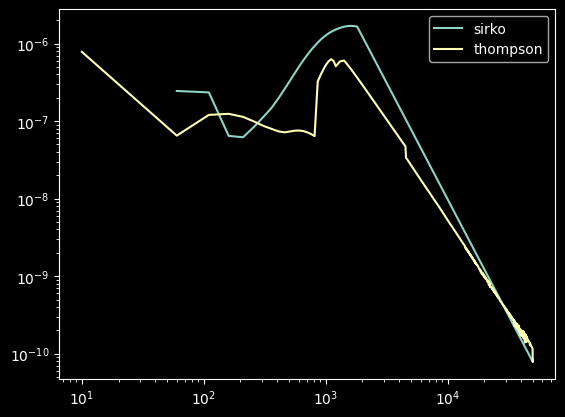

In [5]:
disk_rg = np.linspace(10, 50000, 1000)

s_disk = sirko_agn_disk.disk_density(disk_rg)
t_disk = thompson_agn_disk.disk_density(disk_rg)

plt.plot(disk_rg, s_disk, label="sirko")
plt.plot(disk_rg, t_disk, label="thompson")
plt.loglog()

plt.legend()

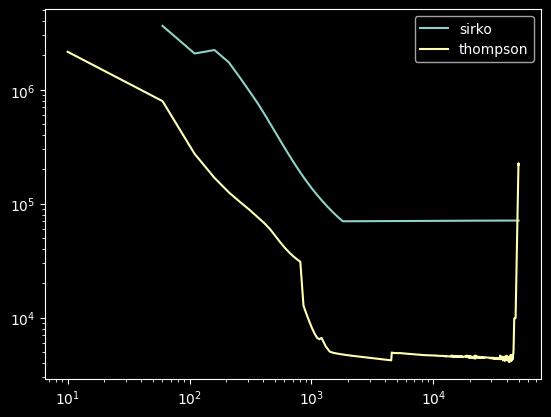

In [6]:
disk_rg = np.linspace(10, 50000, 1000)

s_disk = sirko_agn_disk.disk_sound_speed(disk_rg)
t_disk = thompson_agn_disk.disk_sound_speed(disk_rg)

plt.plot(disk_rg, s_disk, label="sirko")
plt.plot(disk_rg, t_disk, label="thompson")
plt.loglog()

plt.legend()

[-4416413.76115717]


AssertionError: Finite check failure: distance_rg

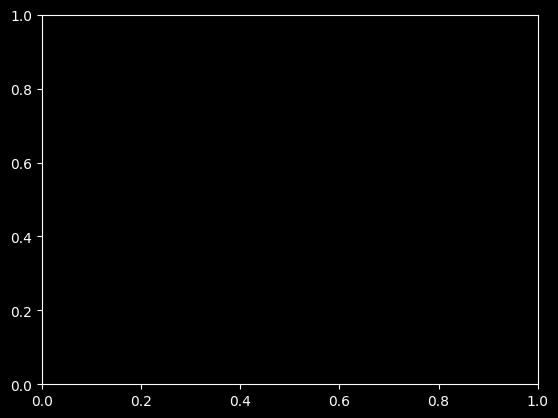

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ---- fixed setup ----
disk  = sirko_agn_disk
dt_yr = 1
smbh  = disk.settings.smbh_mass
r_g_m = disk.settings.r_g_in_meters

orb_a       = np.array([30000.0])   # binary's orbital radius from SMBH [r_g], held fixed
initial_sep = 1                 # binary internal separation [r_g], starting point
m1          = 10.0                  # primary mass [M_sun], held fixed

# q = m_secondary / m_primary (primary = larger);  m2 = m1 / q
mass_ratios = np.linspace(1.0, 0.3, 10)

max_steps = 10000                 # safety cap on the integration

def step_separation(m1, m2, sep):
    """One Stahler-drag timestep; returns the new separation as a float [r_g]."""
    out = stahler_drag(
        np.array([m1]), np.array([m2]), np.array([sep]), orb_a,
        disk.disk_sound_speed, disk.disk_density,
        dt_yr, smbh, r_g_m,
    )
    return float(np.asarray(getattr(out, "value", out)).ravel()[0])

# ---- colour mapping ----
norm = mcolors.Normalize(vmin=mass_ratios.min(), vmax=mass_ratios.max())
cmap = cm.jet_r

fig, ax = plt.subplots()

for q in mass_ratios:
    m2 = m1 / q

    sep = initial_sep
    sep_hist, time_hist = [sep], [0.0]

    for n in range(1, max_steps + 1):
        sep = step_separation(m1, m2, sep)
        if sep <= 0:
            sep_hist.append(0.0)
            time_hist.append(n * dt_yr)
            break
        sep_hist.append(sep)
        time_hist.append(n * dt_yr)

    ax.plot(time_hist, sep_hist, color=cmap(norm(q)), label=f"q = {q:.2f}")

ax.set_xlabel("Time (yr)")
ax.set_ylabel("Binary separation ($r_g$)")
ax.set_ylim(0, None)
#ax.set_xscale("log")


sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mass ratio $q = m_2/m_1$")

plt.show()